#Install Libaries & Get data

In [55]:
import torch
from transformers import SegformerConfig, SegformerForSemanticSegmentation

# Check if GPU is available
device = torch.device("cpu" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [56]:
import torch
import torch.nn as nn
from torchvision import models
from torch.nn.functional import relu

# Get Dataset from Kaggle and Process Masks

text

#Dataset and Dataloaders

In [57]:
import rasterio
import numpy as np
import os
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms
import numpy as np
import torch.nn.functional as F



def load_and_preprocess(path):
    with rasterio.open(path) as src:
        # Read all bands
        img = src.read()

        # Replace No-Data (example: -9999) with 0
        img[img == src.nodata] = 0

        # Robust Scaling (2nd and 98th percentile to remove outliers)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip(img, p2, p98)
        img = (img - p2) / (p98 - p2)

    return img.astype(np.float32)

# Helper function to load raw mask data (without scaling or robust percentile clipping)
# Assumes single-channel mask where pixel values are class labels
def load_raw_mask(path):
    with rasterio.open(path) as src:
        mask_np = src.read()
        # Replace No-Data with 4 (or a specific background class ID)
        if src.nodata is not None:
            mask_np[mask_np == src.nodata] = 4

        # Recode classes 2 and 3 to 0
        #mask_np[mask_np == 2] = 0
        #mask_np[mask_np == 3] = 0
    return mask_np.astype(np.int64) # Masks are typically integer class labels

def get_filename_without_extension(file_path):
    # Extract the base name (filename + extension) from the full path
    base_name = os.path.basename(file_path)
    # Split the base name into root and extension, and return the root
    file_name_without_extension = os.path.splitext(base_name)[0]
    return file_name_without_extension

def one_hot_encode_mask(mask_tensor, num_classes, target_size):
    # Ensure mask_tensor is on CPU for one_hot operation if it's on GPU
    mask_tensor = mask_tensor.cpu() # mask_tensor is (1, H, W) from load_raw_mask

    # Squeeze the channel dimension to get (H, W) before resizing
    # Then, add a channel dimension (1, H, W) for transforms.Resize to operate correctly on spatial dimensions,
    # and squeeze it back to (H_new, W_new) after resizing.
    resized_mask_with_channel = transforms.Resize(target_size, interpolation=transforms.InterpolationMode.NEAREST)(
        mask_tensor.squeeze(0).unsqueeze(0) # (H, W) -> (1, H, W) for Resize input
    )
    resized_mask = resized_mask_with_channel.squeeze(0).long() # (H_new, W_new) after removing the temporary channel dim

    # Perform one-hot encoding on the (H_new, W_new) tensor
    # Output will be (H_new, W_new, num_classes)
    one_hot_mask = F.one_hot(resized_mask, num_classes=num_classes)

    # Reshape to (num_classes, H, W) for consistency with model output
    one_hot_mask = one_hot_mask.permute(2, 0, 1).float()
    return one_hot_mask

In [106]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np
from torchvision import transforms # Make sure this is imported if used later in __getitem__

class TrainingDataset(Dataset):
    def __init__(self, image_paths, label_paths, processor, num_classes=5, data_augmentation_transforms = None, two_damage_levels = False):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.processor = processor # Store the processor
        self.num_classes = num_classes
        self.two_damage_levels = two_damage_levels
        self.data_augmentation_transforms = data_augmentation_transforms # The processor usually handles all transformations
        print(f"TrainingDataset initialized for {self.num_classes}-class segmentation using SegformerImageProcessor.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_np = load_and_preprocess(self.image_paths[index])

        # Convert image_np (C, H, W) to a PIL Image (H, W, C) for torchvision transforms
        # which expect PIL Image for operations like Resize. Also handle 4 channels.
        if image_np.shape[0] == 3: # Assuming RGB
            image_pil = Image.fromarray((image_np.transpose(1, 2, 0) * 255).astype(np.uint8))
        elif image_np.shape[0] == 4: # Assuming RGB-NIR, take only RGB
            # Select the first 3 channels (R, G, B) and transpose for PIL
            image_pil = Image.fromarray((image_np[:3, :, :].transpose(1, 2, 0) * 255).astype(np.uint8))
        elif image_np.shape[0] == 1: # Assuming grayscale
            image_pil = Image.fromarray((image_np.squeeze(0) * 255).astype(np.uint8))
        else:
            raise ValueError(f"Unsupported image channel count: {image_np.shape[0]} for PIL conversion")

        
        # Load the raw mask
        mask_np_raw = load_raw_mask(self.label_paths[index]) # Returns (1, H, W) numpy array
        # Remove channel dimension for augmentation: (1, H, W) -> (H, W)
        mask_np = mask_np_raw.squeeze(0)

        # Apply data augmentation transforms to both image and mask if provided
        # v2.Compose handles synchronized transformations for both PIL images and numpy arrays
        if self.data_augmentation_transforms is not None:
            # Convert image to tensor for augmentation
            image_tensor = transforms.ToTensor()(image_pil)  # Shape: (3, H, W)
            mask_tensor = torch.from_numpy(mask_np).long()  # Shape: (H, W)
            # CRITICAL FIX: Add channel dimension to mask to match image format (C, H, W)
            # mask_tensor becomes (1, H, W) so RandomRotation and flips work on both
            mask_tensor = mask_tensor.unsqueeze(0)  # (H, W) -> (1, H, W)
            
            stacked = torch.cat([image_tensor, mask_tensor.float()], dim=0)  # (C+1, H, W)
            # Apply the same augmentation to both image and mask
            # v2 transforms work with tensors and apply consistently to all inputs
            augmented = self.data_augmentation_transforms(stacked)  # (C+1, H, W)
            # Split back into image and mask
            image_tensor = augmented[:3, :, :]  # (3, H, W)
            mask_tensor = augmented[3:, :, :].long()  # (1, H, W)
            #image_tensor = self.data_augmentation_transforms(image_tensor)
            #mask_tensor = self.data_augmentation_transforms(mask_tensor)
            
            # Convert back to PIL/numpy for processor
            image_pil = transforms.ToPILImage()(image_tensor)
            # Remove the channel dimension we added: (1, H, W) -> (H, W)
            mask_np = mask_tensor.squeeze(0).numpy().astype(np.int64)
        else:
            # If no augmentation, just ensure mask is 2D for processor
            mask_np = mask_np.astype(np.int64)

        if self.two_damage_levels:
            # Recode classes 2 to 1 and 3 and 4 to 2 for two damage levels
            mask_np[mask_np == 2] = 1
            mask_np[mask_np == 3] = 2
            mask_np[mask_np == 4] = 2
            #print(f"Re-coded mask for two damage levels: unique classes {np.unique(mask_np)}")

        # Use the processor to prepare inputs
        # The processor handles resizing, normalization, and converting to tensors
        # reduce_labels=False is crucial to keep our 5 classes
        encoded_inputs = self.processor(images=image_pil, segmentation_maps=mask_np, return_tensors="pt", reduce_labels=False)

        # The processor returns a dictionary with 'pixel_values' and 'labels'
        # Labels need to be of type long for CrossEntropyLoss. SegformerImageProcessor already does this.
        # It also handles resizing the mask using nearest neighbor.

        return {
            "pixel_values": encoded_inputs["pixel_values"].squeeze(0), # Remove batch dim added by processor
            "labels": encoded_inputs["labels"].squeeze(0) # Remove batch dim added by processor
        }

In [83]:
import os
import glob
import random
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from transformers import SegformerImageProcessor # Import the processor
import torch
import numpy as np

def get_data_loaders(batch_size=4, subset_size=None, undersampling_ratio=0.0, minority_class_threshold=0.2, return_dataset = False, data_augmentation_transforms = None, processor=None, use_two_damage_levels = False):
    base_path = '/Users/yujiewu/SP/haiti_cropped_smaller'
    image_dir = os.path.join(base_path, 'images')
    label_dir = os.path.join(base_path, 'labels')

    all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*_post_disaster*.tif')))
    all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*_post_disaster*.tif')))

    if len(all_image_paths) != len(all_label_paths):
        raise ValueError("Mismatch between number of images and labels.")

    all_pairs = list(zip(all_image_paths, all_label_paths))
    train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

    if subset_size is not None:
        train_pairs = train_pairs[:subset_size]
        val_pairs = val_pairs[:subset_size // 4]

    train_image_paths = [p[0] for p in train_pairs]
    train_label_paths = [p[1] for p in train_pairs]

    val_image_paths = [p[0] for p in val_pairs]
    val_label_paths = [p[1] for p in val_pairs]

    print(f"Training images: {len(train_image_paths)}")
    print(f"Validation images: {len(val_image_paths)}")

    train_dataset = TrainingDataset(
        image_paths=train_image_paths,
        label_paths=train_label_paths,
        processor=processor, # Pass the processor
        data_augmentation_transforms=data_augmentation_transforms,
        two_damage_levels=use_two_damage_levels,
    )

    val_dataset = TrainingDataset(
        image_paths=val_image_paths,
        label_paths=val_label_paths,
        processor=processor, # Pass the processor
        two_damage_levels=use_two_damage_levels,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )
    # Return the datasets instead of dataloaders
    if return_dataset:
      return {'train': train_dataset, 'val': val_dataset}
    else:
      return {'train': train_loader, 'val': val_loader}

print("Function `get_data_loaders` defined using SegformerImageProcessor.")


Function `get_data_loaders` defined using SegformerImageProcessor.


#Model Setup

In [84]:
#data augmentation
from torchvision.transforms import ColorJitter, RandomHorizontalFlip, RandomVerticalFlip, RandomRotation
from torchvision.transforms import v2

jitter = ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
flip_h = RandomHorizontalFlip(p=0.5)
flip_v = RandomVerticalFlip(p=0.5)
rotation = RandomRotation(degrees=15)

data_augmentation_transforms = v2.Compose([
    #flip_h,
    #flip_v,
    rotation
]) 

def train_transforms(example_batch):
    images = [jitter(x) for x in example_batch['pixel_values']]
    images = [flip_h(x) for x in images]
    images = [flip_v(x) for x in images]
    images = [rotation(x) for x in images]

    labels = [x for x in example_batch['label']]
    labels = [flip_h(x) for x in labels]
    labels = [flip_v(x) for x in labels]
    labels = [rotation(x) for x in labels]
    inputs = processor(images, labels)
    return inputs

def val_transforms(example_batch):
    images = [x for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = processor(images, labels)
    return inputs


In [72]:
#pretrained
# We'll use the 'mit-b0' variant fine-tuned on the ADE20k dataset
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"

# Load the model and move it to the GPU
model = SegformerForSemanticSegmentation.from_pretrained(model_name)
model.to(device)

print("Pre-trained model loaded successfully!")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Pre-trained model loaded successfully!


In [73]:
from transformers import TrainingArguments

epochs = 30
lr = 0.00006
batch_size = 2

hub_model_id = "segformer-earthquake-damage-assessment"

training_args = TrainingArguments(
    #"segformer-b0-finetuned-segments-sidewalk-outputs",
    learning_rate=lr,
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    save_total_limit=3,
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    load_best_model_at_end=True,
    push_to_hub=False,
    hub_model_id=hub_model_id,
    hub_strategy="end",
    use_cpu=True
)

In [117]:
id2label = {
    0: "un-classified",
    1: "no-damage",
    2: "minor-damage",
    3: "major-damage",
    4: "destroyed" # This mapping is consistent with the damage_to_idx from create_multi_label_mask
}
'''
id2label= { #override prev definition for two damage levels
    0: "un-classified",
    1: "no-damage",
    2: "damage" # This mapping is consistent with the damage_to_idx from create_multi_label_mask
}
'''
label2id = {v: k for k, v in id2label.items()}

In [76]:
import torch
from torch import nn
import evaluate

metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
  with torch.no_grad():
    logits, labels = eval_pred
    logits_tensor = torch.from_numpy(logits)
    # scale the logits to the size of the label
    logits_tensor = nn.functional.interpolate(
        logits_tensor,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False,
    ).argmax(dim=1)

    pred_labels = logits_tensor.detach().cpu().numpy()
    metrics = metric.compute(
        predictions=pred_labels,
        references=labels,
        num_labels=len(id2label),
        ignore_index=0,
        reduce_labels=processor.do_reduce_labels,
    )

    # add per category metrics as individual key-value pairs
    per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
    per_category_iou = metrics.pop("per_category_iou").tolist()

    metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
    metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})

    return metrics

In [125]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "nvidia/mit-b0"

# Define ID to Label and Label to ID mappings for 5-class damage segmentation
num_labels = len(id2label) # Should be 5
print(f"Number of labels: {num_labels}")

model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)


Number of labels: 5


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)
/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


Training images: 281
Validation images: 71
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.


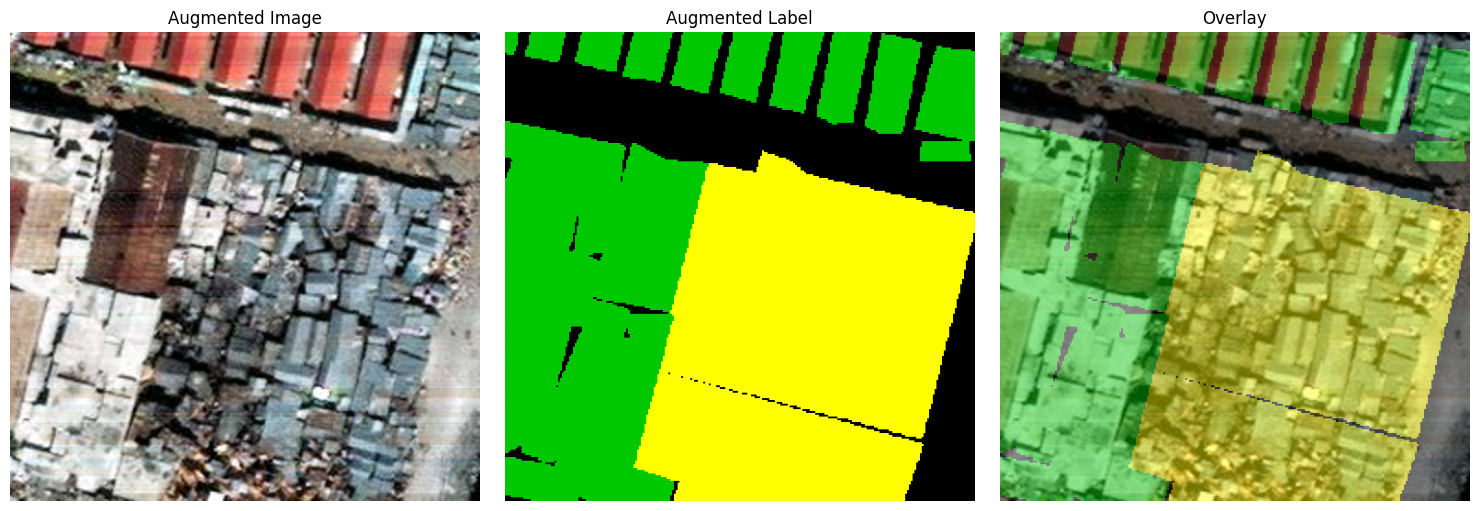

Unique classes in shown mask: [0 1 2]


In [122]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import MinMaxScaler

# Build loaders with augmentation enabled (applied in TrainingDataset.__getitem__)

checkpoint = "nvidia/segformer-b0-finetuned-ade-512-512"
processor = SegformerImageProcessor.from_pretrained(checkpoint, do_rescale=False, do_reduce_labels=False)
scaler = MinMaxScaler()

dataloaders_aug = get_data_loaders(
    batch_size=4,
    #data_augmentation_transforms=data_augmentation_transforms,
    processor= processor,
    use_two_damage_levels= False
)

# Get one augmented batch from train split
batch = next(iter(dataloaders_aug["train"]))
images = batch["pixel_values"]   # (B, 3, H, W), normalized by processor
labels = batch["labels"]         # (B, H, W)

# Pick one sample
idx = 0
img_t = images[idx].cpu()
mask = labels[idx].cpu().numpy()

# De-normalize image for display (uses processor stats)
mean = torch.tensor(processor.image_mean).view(-1, 1, 1)
std = torch.tensor(processor.image_std).view(-1, 1, 1)
#img = (img_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
img = np.transpose(img_t, (1, 2, 0)).numpy()

img = [scaler.fit_transform(img[x]) for x in range(img.shape[0])]


# Class colors for 5 classes: 0..4
class_colors = np.array([
    [0,   0,   0],    # un-classified
    [0,   200, 0],    # no-damage
    [255, 255, 0],    # minor-damage
    [255, 140, 0],    # major-damage
    [200, 0,   0],    # destroyed
], dtype=np.uint8)
cmap = ListedColormap(class_colors / 255.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title("Augmented Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap=cmap, vmin=0, vmax=4)
axes[1].set_title("Augmented Label")
axes[1].axis("off")

axes[2].imshow(img)
axes[2].imshow(mask, cmap=cmap, vmin=0, vmax=4, alpha=0.45)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Optional: inspect class IDs present in this label
print("Unique classes in shown mask:", np.unique(mask))

In [118]:
from transformers import Trainer
from transformers import SegformerImageProcessor

# Use the same checkpoint name you used for the model
checkpoint = "nvidia/segformer-b0-finetuned-ade-512-512"

# Load the processor
# Set do_rescale=False because images are already scaled by load_and_preprocess
# Set do_reduce_labels=False to keep all 5 damage classes
processor = SegformerImageProcessor.from_pretrained(checkpoint, do_rescale=False, do_reduce_labels=False)

print(processor)

dataloader = get_data_loaders(return_dataset = True, processor=processor, use_two_damage_levels=False)
train_dataset = dataloader["train"]
val_dataset = dataloader["val"]


SegformerImageProcessor {
  "do_normalize": true,
  "do_reduce_labels": false,
  "do_rescale": false,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "SegformerImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 512,
    "width": 512
  }
}

Training images: 281
Validation images: 71
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.


/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


In [126]:
processor = SegformerImageProcessor.from_pretrained(checkpoint, do_rescale=False, do_reduce_labels=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Step,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Overall Accuracy,Accuracy Un-classified,Accuracy No-damage,Accuracy Minor-damage,Accuracy Major-damage,Accuracy Destroyed,Iou Un-classified,Iou No-damage,Iou Minor-damage,Iou Major-damage,Iou Destroyed
20,1.383118,1.536118,0.114717,0.248051,0.340673,nan,0.275359,0.668297,0.028412,0.020137,0.000000,0.196325,0.332568,0.025559,0.019132
40,1.265543,1.463445,0.089035,0.238834,0.318306,nan,0.794712,0.142003,0.000327,0.018296,0.000000,0.312658,0.114289,0.000326,0.017901
60,1.331697,1.259944,0.101062,0.241941,0.341927,nan,0.178038,0.777364,0.001775,0.010586,0.000000,0.150126,0.342898,0.001765,0.010523
80,1.257552,1.333759,0.111634,0.261486,0.366694,nan,0.255981,0.771292,0.007131,0.011542,0.000000,0.195525,0.344223,0.006990,0.011432
100,1.268228,1.044077,0.101982,0.214522,0.296205,nan,0.440316,0.412091,0.000006,0.005675,0.000000,0.251499,0.252745,0.000006,0.005662
120,1.212163,1.056530,0.103874,0.225485,0.306671,nan,0.492836,0.385907,0.001024,0.022174,0.000000,0.259924,0.236492,0.001017,0.021935
140,0.977781,1.008132,0.115834,0.235913,0.315908,nan,0.384594,0.494495,0.010633,0.053928,0.000000,0.236906,0.280408,0.010265,0.051592
160,0.953785,1.039588,0.111529,0.252348,0.349584,nan,0.200439,0.766016,0.004217,0.038721,0.000000,0.171437,0.344363,0.004165,0.037679
180,1.074877,0.993916,0.113137,0.236685,0.311482,nan,0.570764,0.311894,0.000000,0.064081,0.000000,0.300769,0.203908,0.000000,0.061008
200,1.166677,0.977698,0.145606,0.274659,0.344356,nan,0.318525,0.573434,0.087363,0.119313,0.000000,0.234871,0.315798,0.070527,0.106836


/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/datasets/features/image.py:377: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/Users/yujiewu/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)
/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/datasets/features/image.py:377: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/Users/yujiewu/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)
/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/datasets/features/image.py:377: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/Users/yujiewu/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4230, training_loss=0.6289998045345289, metrics={'train_runtime': 15633.2839, 'train_samples_per_second': 0.539, 'train_steps_per_second': 0.271, 'total_flos': 1.4779133367681024e+17, 'train_loss': 0.6289998045345289, 'epoch': 30.0})

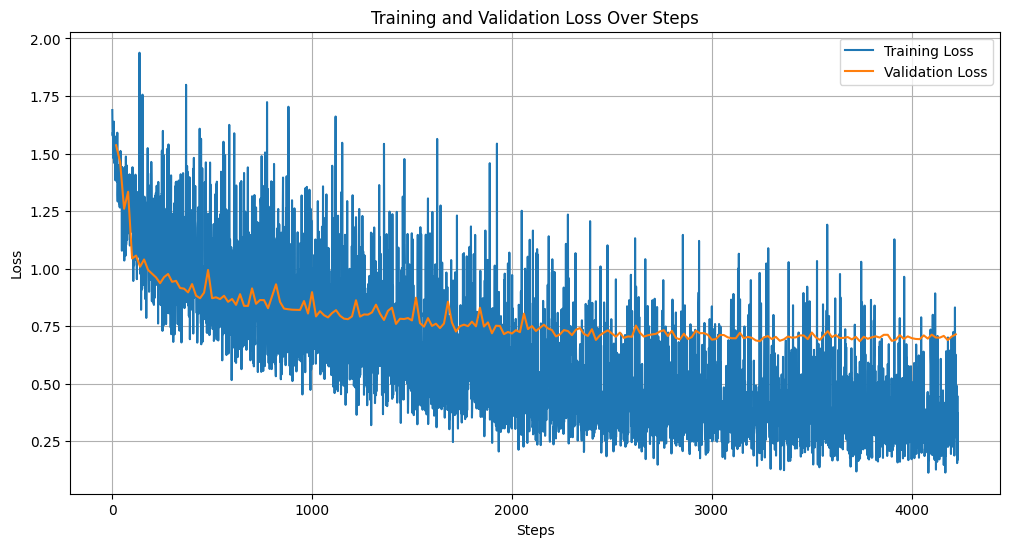

"\n# Plotting evaluation metrics\nplt.figure(figsize=(12, 8))\nfor metric_name, values in eval_metrics.items():\n    if values: # Only plot if there are values for the metric\n        plt.plot(eval_steps, values, label=metric_name)\n\nplt.xlabel('Steps')\nplt.ylabel('Metric Value')\nplt.title('Validation Metrics Over Steps')\nplt.legend()\nplt.grid(True)\nplt.show()\n"

In [127]:
import matplotlib.pyplot as plt

# Extract training and evaluation logs
log_history = trainer.state.log_history

train_losses = []
eval_losses = []
steps = []

# Metrics to plot
eval_metrics = {
    'eval_loss': [],
    'eval_mean_iou': [],
    'eval_accuracy_background': [],
    'eval_accuracy_road': [],
    'eval_iou_background': [],
    'eval_iou_road': [],
}

for log in log_history:
    if 'loss' in log: # Training loss
        train_losses.append(log['loss'])
        steps.append(log['step'])
    if 'eval_loss' in log: # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        for key in eval_metrics.keys():
            if key in log:
                eval_metrics[key].append(log[key])

# Plotting training and evaluation loss
plt.figure(figsize=(12, 6))
plt.plot(steps[:len(train_losses)], train_losses, label='Training Loss')

# Match eval_losses to the steps where evaluation happened
eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]
plt.plot(eval_steps, eval_losses, label='Validation Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Steps')
plt.legend()
plt.grid(True)
plt.show()
'''
# Plotting evaluation metrics
plt.figure(figsize=(12, 8))
for metric_name, values in eval_metrics.items():
    if values: # Only plot if there are values for the metric
        plt.plot(eval_steps, values, label=metric_name)

plt.xlabel('Steps')
plt.ylabel('Metric Value')
plt.title('Validation Metrics Over Steps')
plt.legend()
plt.grid(True)
plt.show()
'''

/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


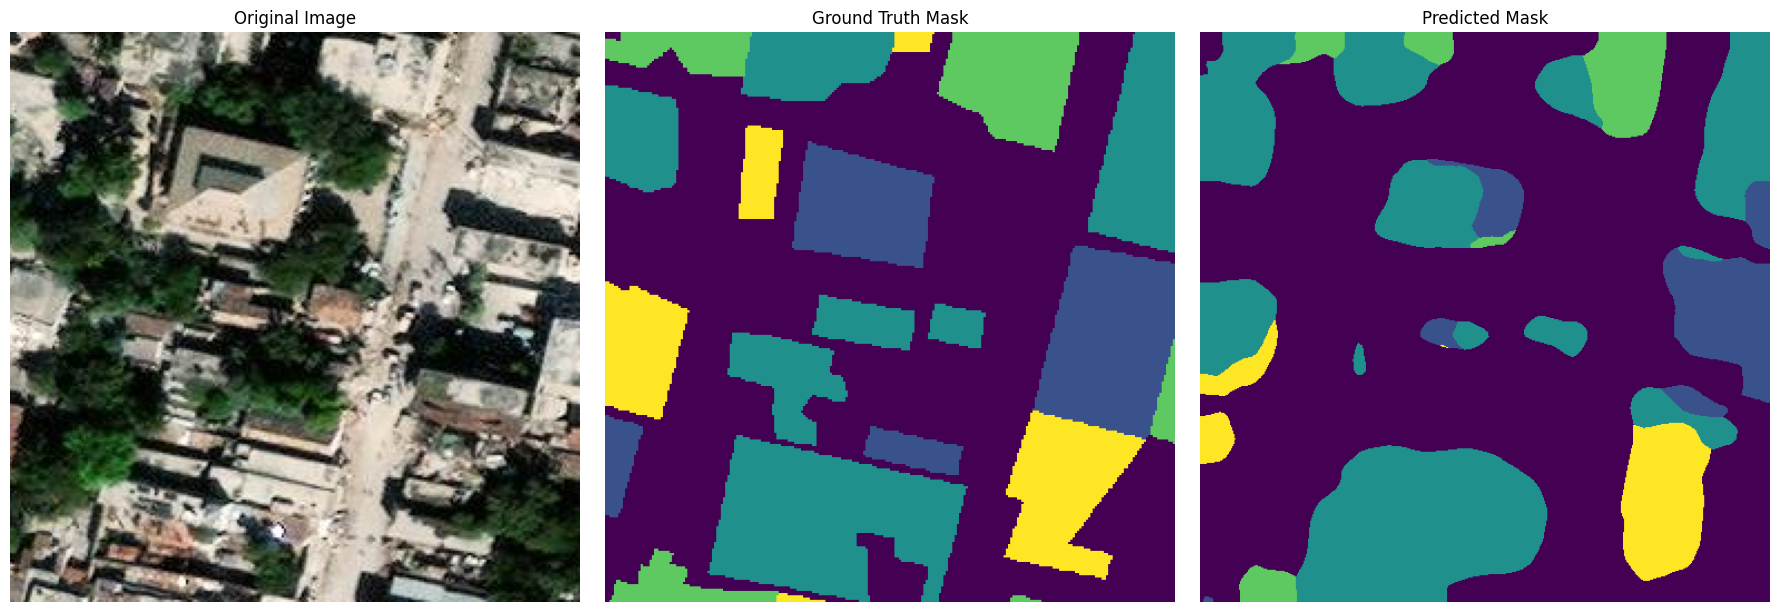

In [128]:
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# Get a sample from the validation dataset
val_dataset = dataloader['val']

# Randomly select an index
idx = 0#random.randint(0, len(val_dataset) - 1)

# Get the item from the dataset
sample = val_dataset[idx]
image_tensor = sample['pixel_values']
label_tensor = sample['labels']

# Retrieve the original image and label paths for better visualization reference
original_image_path = val_dataset.image_paths[idx]
original_label_path = val_dataset.label_paths[idx]

# Load and preprocess the original image for display (without normalization/tensor conversion)
# The `image_tensor` is already normalized and ready for the model.
# We need the original, denormalized image for visual comparison.
original_image_display = Image.open(original_image_path)

# Move image tensor to the correct device for inference
inputs = image_tensor.unsqueeze(0).to(device) # Add batch dimension

# Perform inference
model.eval()
with torch.no_grad():
    outputs = model(inputs)

# Get predicted logits and convert to predicted labels
logits = outputs.logits

# Resize logits to the original label size (from the dataset item) for comparison
# and then take argmax to get class predictions
predicted_mask_tensor = torch.nn.functional.interpolate(
    logits,
    size=label_tensor.shape[-2:], # target size is H, W of the ground truth label
    mode="bilinear",
    align_corners=False
).argmax(dim=1).squeeze(0)

predicted_mask_np = predicted_mask_tensor.cpu().numpy()

# Ground truth mask (from the dataset item, already preprocessed and resized)
# Add a channel dimension for masks_to_colorimg to work correctly (expects C, H, W)
ground_truth_mask_np = label_tensor.unsqueeze(0).cpu().numpy()

# Convert masks to color images using the defined function
colored_ground_truth = np.transpose(ground_truth_mask_np, (1, 2, 0))
colored_prediction = predicted_mask_np#.reshape(1, *predicted_mask_np.shape) # dont Reshape to (1, H, W)

# Plot the original image, ground truth, and prediction
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(colored_ground_truth)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(colored_prediction)
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

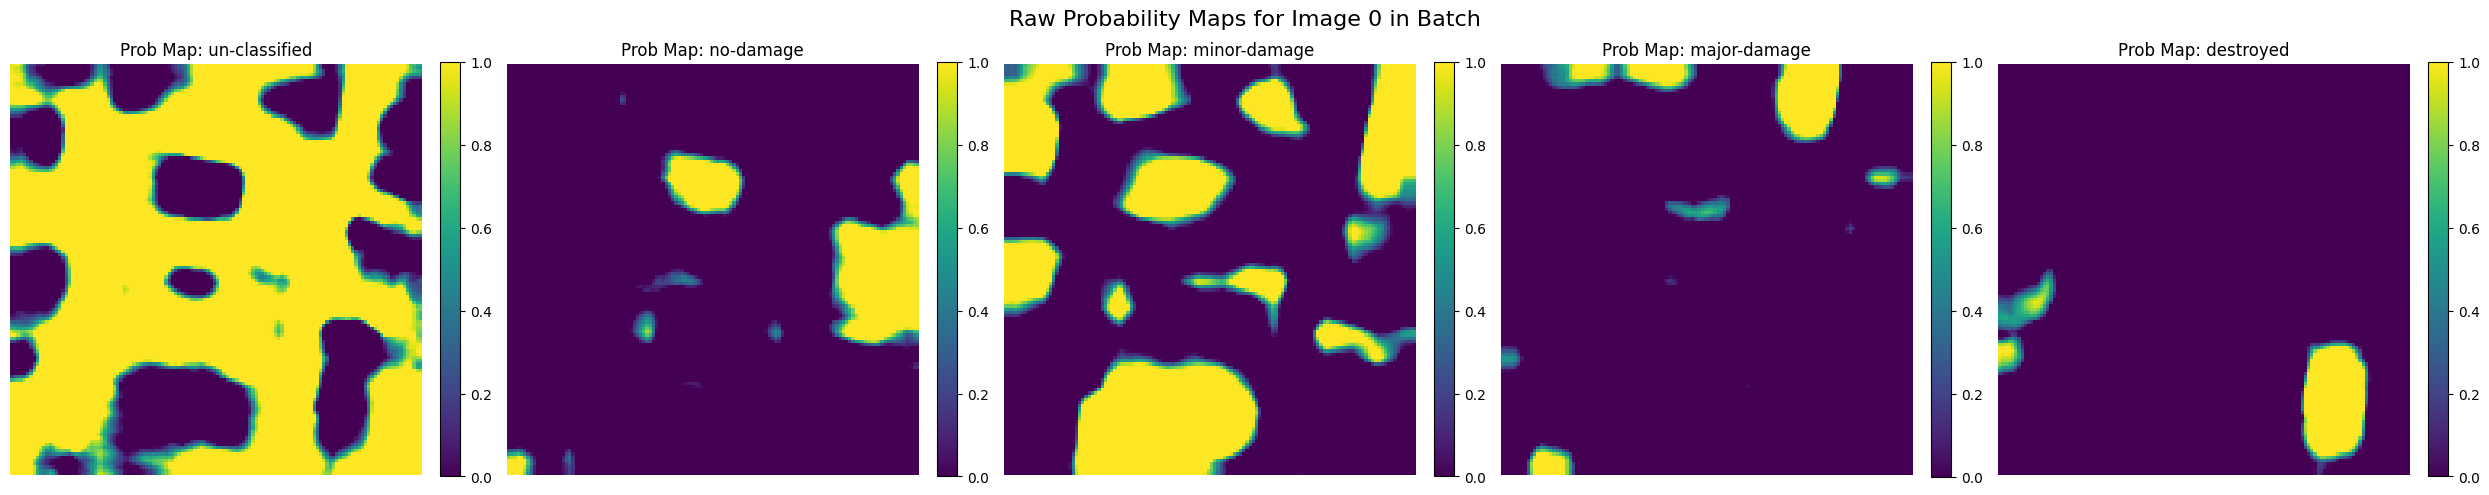

In [129]:
import matplotlib.pyplot as plt
import numpy as np

def plot_probability_maps(predictions, damage_to_idx, image_index=0):
    """
    Plots the raw probability maps for each class from the model's predictions.

    Args:
        predictions (torch.Tensor or np.ndarray): Model output tensor of shape
                                                  (batch_size, num_classes, H, W).
        damage_to_idx (dict): Dictionary mapping damage type names to class indices.
        image_index (int): The index of the image in the batch to visualize.
    """
    # Ensure predictions is a NumPy array
    if isinstance(predictions, torch.Tensor):
        predictions = predictions.cpu().numpy()

    batch_size, num_classes, height, width = predictions.shape

    if image_index >= batch_size:
        print(f"Warning: image_index {image_index} is out of bounds for batch size {batch_size}. Using image_index 0.")
        image_index = 0

    fig, axes = plt.subplots(1, num_classes, figsize=(num_classes * 5, 5))
    if num_classes == 1: # Handle case with a single class
        axes = [axes]

    # Invert the damage_to_idx to get class name from index for titles
    idx_to_damage = {v: k for k, v in damage_to_idx.items()}

    for class_idx in range(num_classes):
        ax = axes[class_idx]
        class_name = idx_to_damage.get(class_idx, f'Class {class_idx}')

        # Extract the probability map for the current class and image
        prob_map = predictions[image_index, class_idx, :, :]

        im = ax.imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'Prob Map: {class_name}')
        ax.axis('off')

        # Add a colorbar for each subplot
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.suptitle(f'Raw Probability Maps for Image {image_index} in Batch', y=1.02, fontsize=16)
    plt.show()

# Call the function with the 'pred' tensor and 'damage_to_idx'
# Assuming 'pred' and 'damage_to_idx' are available from previous execution

# Perform inference
model.eval()
with torch.no_grad():
    outputs = model(inputs)

# Get predicted logits and convert to predicted labels
logits = outputs.logits

# Resize logits to the original label size (from the dataset item) for comparison
# and then take argmax to get class predictions
predicted_mask_tensor = torch.nn.functional.interpolate(
    logits,
    size=label_tensor.shape[-2:], # target size is H, W of the ground truth label
    mode="bilinear",
    align_corners=False
).argmax(dim=1).squeeze(0)

predicted_mask_np = predicted_mask_tensor.cpu().numpy()


plot_probability_maps(logits, label2id)


In [131]:
import torch
import numpy as np

class SegmentationMetrics:
    """
    Accumulates a confusion matrix over the full val set,
    then computes per-class and mean IoU + F1.
    """
    def __init__(self, num_classes: int, class_names: list[str], ignore_index: int = 255):
        self.num_classes = num_classes
        self.class_names = class_names
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """
        preds:   (B, H, W) — argmax class indices
        targets: (B, H, W) — ground truth class indices
        """
        preds = preds.cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()

        # Mask out ignored pixels
        mask = targets != self.ignore_index
        preds, targets = preds[mask], targets[mask]

        # Accumulate into confusion matrix
        indices = self.num_classes * targets + preds
        counts = np.bincount(indices, minlength=self.num_classes ** 2)
        self.confusion_matrix += counts.reshape(self.num_classes, self.num_classes)

    def compute(self) -> dict:
        cm = self.confusion_matrix  # shape: (C, C)

        # Per-class IoU
        tp = np.diag(cm)                          # true positives per class
        fp = cm.sum(axis=0) - tp                  # false positives
        fn = cm.sum(axis=1) - tp                  # false negatives

        iou = tp / (tp + fp + fn + 1e-6)

        # Per-class F1
        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        results = {
            "per_class_iou":  dict(zip(self.class_names, iou)),
            "per_class_f1":   dict(zip(self.class_names, f1)),
            "miou":           float(np.mean(iou)),
            "mean_f1":        float(np.mean(f1)),
        }
        return results

#calcualte metrics
dataloader = get_data_loaders(use_two_damage_levels=False, processor=processor, return_dataset=False)
# Get a sample from the validation dataset
val_loader = dataloader['val']
metrics_calculator = SegmentationMetrics(num_classes=5, class_names=list(id2label.values()), ignore_index=0) # Fixed num_classes to 5 and used id2label.values()
#iterate through entire val dataset and calculate mIoU for each class and mean IoU
ious_per_class = []
mean_ious = []
for batch in val_loader:
    inputs = batch["pixel_values"].to(device)
    labels = batch["labels"].to(device)

    with torch.no_grad():
        outputs = model(inputs)

    # Get predicted logits and convert to predicted labels
    logits = outputs.logits

    predicted_mask_tensor = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:], # target size is H, W of the ground truth label
        mode="bilinear",
        align_corners=False
    ).argmax(dim=1)

    # labels are already 0 or 1 from TrainingDataset
    # No need for F.softmax or remap_labels as per user request and dataset prep

    # Update IoU metrics
    metrics_calculator.update(predicted_mask_tensor.cpu(), labels.cpu())

results = metrics_calculator.compute()
print("Per-class IoU:", results["per_class_iou"])
print("Per-class F1:", results["per_class_f1"])
print("Mean IoU:", results["miou"])
print("Mean F1:", results["mean_f1"])


Training images: 281
Validation images: 71
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.


/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)


Per-class IoU: {'un-classified': np.float64(0.0), 'no-damage': np.float64(0.5560925878432368), 'minor-damage': np.float64(0.5187526925066995), 'major-damage': np.float64(0.4433266470056017), 'destroyed': np.float64(0.37691198054412167)}
Per-class F1: {'un-classified': np.float64(0.0), 'no-damage': np.float64(0.7147289366090832), 'minor-damage': np.float64(0.6831294083804057), 'major-damage': np.float64(0.6143117875017616), 'destroyed': np.float64(0.5474738636187354)}
Mean IoU: 0.37901678157993196
Mean F1: 0.5119287992219971


In [ ]:
from transformers import SegformerImageProcessor
processor = SegformerImageProcessor(do_reduce_labels=True)

In [ ]:
from transformers import SegformerModel, SegformerConfig

# Initializing a SegFormer nvidia/segformer-b0-finetuned-ade-512-512 style configuration
configuration = SegformerConfig()

# Initializing a model from the nvidia/segformer-b0-finetuned-ade-512-512 style configuration
model = SegformerModel(configuration)

# Accessing the model configuration
configuration = model.config

#??????

In [ ]:
# Pass the inputs to the model
# Unpacking the dictionary directly feeds 'pixel_values' and 'labels' to the model
outputs = model(**inputs)

# The model automatically computes the Cross-Entropy loss because 'labels' were provided
loss = outputs.loss
logits = outputs.logits

print(f"Calculated Loss: {loss.item()}")
print(f"Logits shape: {logits.shape}")

In [ ]:
import time
import torch

num_class = 2

dataloader = get_data_loaders(batch_size=10, return_dataset=True)
# Get a sample from the validation dataset
val_loader = dataloader['val']

inputs = val_loader[0]["pixel_values"].to(device)
labels = val_loader[0]["labels"].to(device)

# Ensure batch dimension exists
if inputs.ndim == 3:   # [C,H,W] -> [1,C,H,W]
    inputs = inputs.unsqueeze(0)
if labels.ndim == 2:   # [H,W] -> [1,H,W]
    labels = labels.unsqueeze(0)

latency_calc_device = torch.device("cpu")

idx = 0
print(inputs.shape)

# Move image tensor to the correct device for inference
inputs = inputs.to(latency_calc_device)

model = model.to(latency_calc_device) # Move model to the same device as inputs for latency calculation

model.eval()
with torch.no_grad():
    start_time = time.time()
    output = model(inputs)
    latency = (time.time() - start_time) * 1000 / inputs.size(0)  # in milliseconds

print(f"Inference latency (Averaged across {inputs.size(0)} images): {latency:.2f} ms")

Training images: 281
Validation images: 71
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
TrainingDataset initialized for 5-class segmentation using SegformerImageProcessor.
torch.Size([1, 3, 512, 512])
Inference latency (Averaged across 1 images): 150.31 ms


/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.preprocess` and were ignored: 'reduce_labels'
  return self.preprocess(images, *args, **kwargs)
